In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import copy
import time
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
import glob
import random
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


In [4]:
random.seed(42)
np.random.seed(42)

ORIGINAL_DATA_ROOT = os.path.join('..', 'data')
AUGMENTED_DATA_ROOT = os.path.join('..', 'data_augmented')

CLASS_DIRS = {
    '1st degree': 543,
    '2nd degree': 488,
    '3rd degree': 326,
}

TARGET_PER_CLASS = 2000

for cls in CLASS_DIRS:
    os.makedirs(os.path.join(AUGMENTED_DATA_ROOT, cls), exist_ok=True)

print(f'Target images per class : {TARGET_PER_CLASS}')
print(f'Output root             : {AUGMENTED_DATA_ROOT}')


Target images per class : 2000
Output root             : ..\data_augmented


In [5]:
augment_pipeline = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.4),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08),
    transforms.RandomAffine(degrees=20, translate=(0.15, 0.15), shear=15, scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAutocontrast(p=0.2),
    transforms.RandomEqualize(p=0.1),
])

def save_augmented(img, save_path):
    aug = augment_pipeline(img)
    aug.save(save_path, quality=95)


In [6]:
summary = {}

for cls_name, original_count in CLASS_DIRS.items():
    src_dir  = os.path.join(ORIGINAL_DATA_ROOT, cls_name)
    dst_dir  = os.path.join(AUGMENTED_DATA_ROOT, cls_name)
    src_imgs = glob.glob(os.path.join(src_dir, '*'))

    saved = 0

    for src_path in src_imgs:
        fname    = os.path.splitext(os.path.basename(src_path))[0]
        dst_path = os.path.join(dst_dir, f'{fname}_orig.jpg')
        try:
            img = Image.open(src_path).convert('RGB')
            img.save(dst_path, quality=95)
            saved += 1
        except Exception:
            pass

    aug_needed  = TARGET_PER_CLASS - saved
    aug_per_img = int(np.ceil(aug_needed / len(src_imgs)))

    print(f'\n[{cls_name}]  originals={len(src_imgs)}  need {aug_needed} augmented copies  (~{aug_per_img}x per image)')

    counter = 0
    for src_path in tqdm(src_imgs * (aug_per_img + 1), desc=cls_name):
        if saved >= TARGET_PER_CLASS:
            break
        try:
            img   = Image.open(src_path).convert('RGB')
            fname = os.path.splitext(os.path.basename(src_path))[0]
            dst   = os.path.join(dst_dir, f'{fname}_aug_{counter:04d}.jpg')
            save_augmented(img, dst)
            saved   += 1
            counter += 1
        except Exception:
            pass

    final_count = len(glob.glob(os.path.join(dst_dir, '*')))
    summary[cls_name] = final_count
    print(f'  → {final_count} images saved to {dst_dir}')

print('\n=== AUGMENTATION COMPLETE ===')
for cls, cnt in summary.items():
    print(f'  {cls:12s}: {cnt} images')
print(f'  Total: {sum(summary.values())} images')



[1st degree]  originals=543  need 1457 augmented copies  (~3x per image)


1st degree:  67%|██████▋   | 1457/2172 [00:22<00:10, 65.43it/s]


  → 2000 images saved to ..\data_augmented\1st degree

[2nd degree]  originals=488  need 1512 augmented copies  (~4x per image)


2nd degree:  62%|██████▏   | 1512/2440 [00:30<00:18, 49.57it/s]


  → 2000 images saved to ..\data_augmented\2nd degree

[3rd degree]  originals=326  need 1674 augmented copies  (~6x per image)


3rd degree:  73%|███████▎  | 1674/2282 [00:26<00:09, 63.52it/s]

  → 2000 images saved to ..\data_augmented\3rd degree

=== AUGMENTATION COMPLETE ===
  1st degree  : 2000 images
  2nd degree  : 2000 images
  3rd degree  : 2000 images
  Total: 6000 images


In [20]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
CLASS_NAMES = ['1st Degree', '2nd Degree', '3rd Degree']

tta_transforms = [
    val_transforms,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(90, 90)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
]


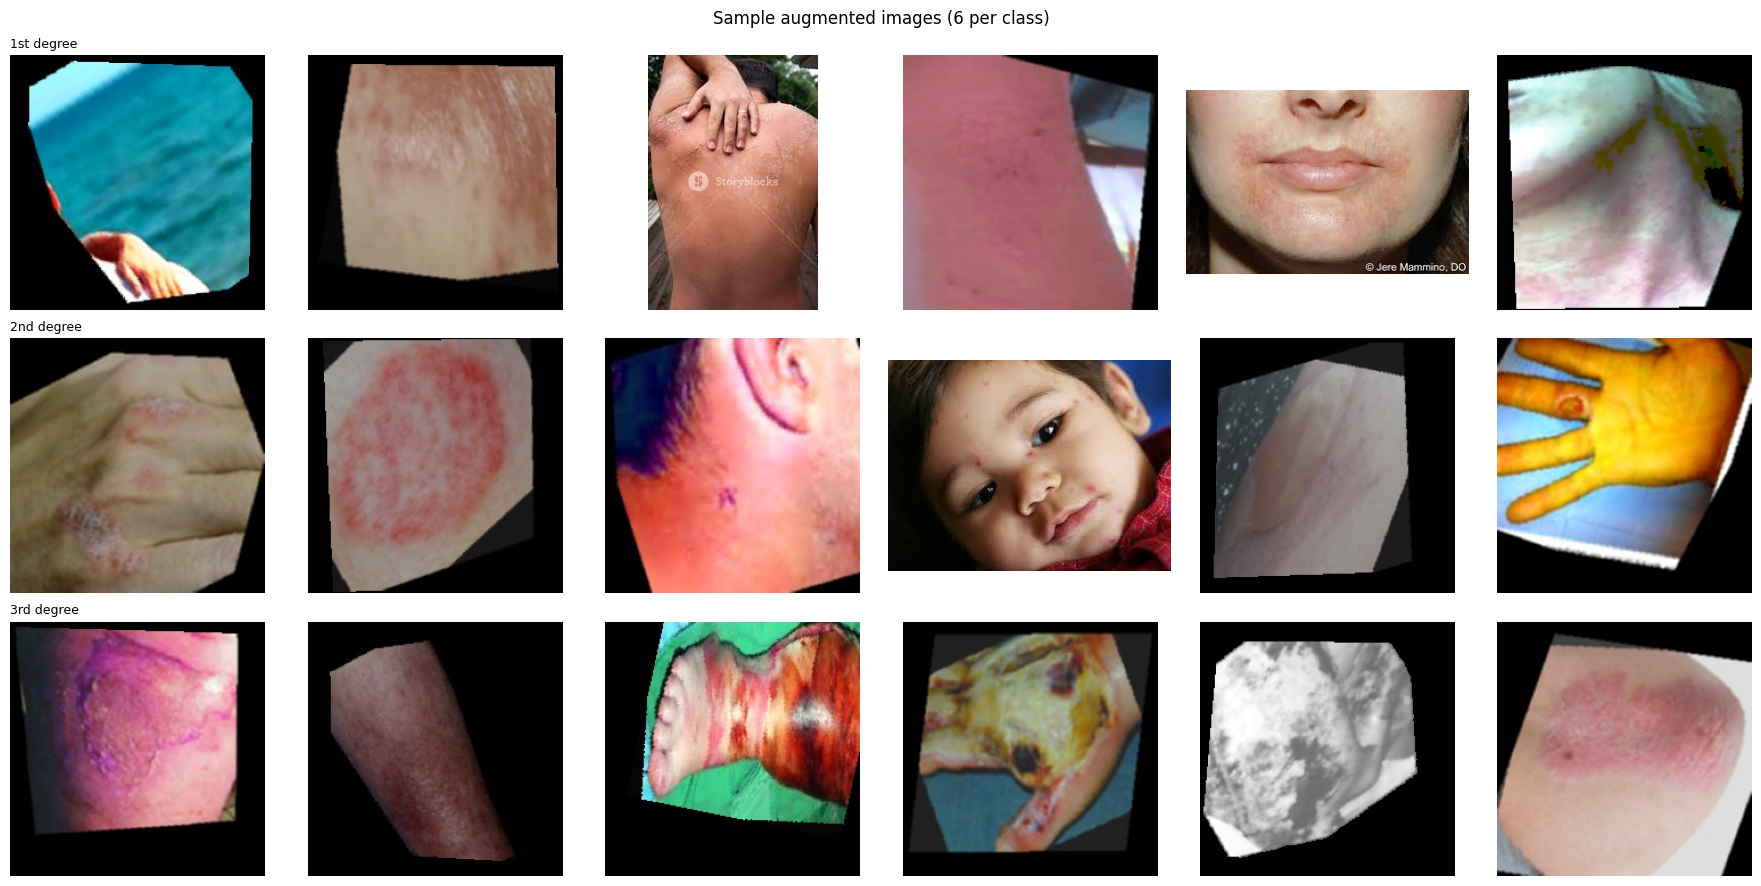

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for row_idx, cls_name in enumerate(CLASS_DIRS):
    dst_dir   = os.path.join(AUGMENTED_DATA_ROOT, cls_name)
    all_files = glob.glob(os.path.join(dst_dir, '*'))
    samples   = random.sample(all_files, min(6, len(all_files)))

    for col_idx, fpath in enumerate(samples):
        ax  = axes[row_idx][col_idx]
        img = Image.open(fpath).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(cls_name, fontsize=9, loc='left')

plt.suptitle('Sample augmented images (6 per class)', fontsize=12)
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=120)
plt.show()


In [ ]:
CLASS_MAP  = {'1st degree': 0, '2nd degree': 1, '3rd degree': 2}
all_paths, all_labels = [], []

for cls_name, lbl in CLASS_MAP.items():
    cls_dir = os.path.join(AUGMENTED_DATA_ROOT, cls_name)
    paths   = glob.glob(os.path.join(cls_dir, '*'))
    all_paths.extend(paths)
    all_labels.extend([lbl] * len(paths))

data = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Total augmented images: {len(data)}')
print(data['label'].value_counts().sort_index())

train_data, temp_data = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)
val_data,  test_data  = train_test_split(temp_data, test_size=0.5, stratify=temp_data['label'], random_state=42)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f'Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}')


Total augmented images: 6000
label
0    2000
1    2000
2    2000
Name: count, dtype: int64
Train: 4800  Val: 600  Test: 600


In [9]:
class BurnDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row   = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


BATCH_SIZE = 32

train_dataset = BurnDataset(train_data, transform=train_transforms)
val_dataset   = BurnDataset(val_data,   transform=val_transforms)
test_dataset  = BurnDataset(test_data,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')


Train batches: 150  Val: 19  Test: 19


In [ ]:
def mixup_batch(images, labels, num_classes=3, alpha=0.4):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    y_a   = F.one_hot(labels,       num_classes=num_classes).float()
    y_b   = F.one_hot(labels[idx],  num_classes=num_classes).float()
    return mixed, lam * y_a + (1 - lam) * y_b


def build_model(num_classes=3, dropout_p=0.4):
    weights = models.EfficientNet_B3_Weights.DEFAULT
    model   = models.efficientnet_b3(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.Dropout(p=dropout_p * 0.5),
        nn.Linear(512, num_classes)
    )
    return model
model = build_model(num_classes=3, dropout_p=0.4)
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

WARMUP_EPOCHS = 5
NUM_EPOCHS    = 50

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=5e-4
)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = None

print(f'Model ready. Train size: {len(train_data)}  (was 949 before augmentation)')


Model ready. Train size: 4800  (was 949 before augmentation)


In [ ]:
def unfreeze_backbone(model, optimizer):
    for param in model.parameters():
        param.requires_grad = True
    backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
    head_params     = list(model.classifier.parameters())
    optimizer.param_groups.clear()
    optimizer.add_param_group({'params': backbone_params, 'lr': 2e-5,  'weight_decay': 1e-4})
    optimizer.add_param_group({'params': head_params,     'lr': 2e-4,  'weight_decay': 1e-4})
    global cosine_scheduler
    cosine_scheduler = OneCycleLR(
        optimizer,
        max_lr=[2e-4, 2e-3],
        steps_per_epoch=len(train_loader),
        epochs=NUM_EPOCHS - WARMUP_EPOCHS,
        pct_start=0.1,
        div_factor=10,
        final_div_factor=100,
        anneal_strategy='cos'
    )
    print(f'Backbone unfrozen. OneCycleLR started.')


def run_epoch(model, loader, criterion, optimizer=None, is_train=True, use_mixup=False):
    model.train() if is_train else model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.set_grad_enabled(is_train):
            if is_train and use_mixup and np.random.random() < 0.5:
                images, soft_labels = mixup_batch(images, labels)
                outputs = model(images)
                loss    = (-soft_labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if cosine_scheduler is not None:
                    cosine_scheduler.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
CHECKPOINT_PATH   = 'best_burn_model.pth'
PATIENCE          = 15
history           = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss     = float('inf')
best_model_wts    = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
backbone_unfrozen = False

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print('-' * 62)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == WARMUP_EPOCHS + 1:
        unfreeze_backbone(model, optimizer)
        backbone_unfrozen = True

    t0 = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, is_train=True,  use_mixup=backbone_unfrozen)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion,            is_train=False)

    if not backbone_unfrozen:
        warmup_scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    marker  = ' ✓' if val_loss < best_val_loss else ''
    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>9.4f} | {val_acc:>8.4f}  ({elapsed:.1f}s){marker}")

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_model_wts    = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, CHECKPOINT_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

model.load_state_dict(best_model_wts)
print(f'\nBest val loss: {best_val_loss:.4f}')


 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
--------------------------------------------------------------
     1 |     1.0077 |    0.5513 |    0.9242 |   0.6250  (107.9s) ✓
     2 |     0.9119 |    0.5998 |    0.8511 |   0.6567  (42.9s) ✓
     3 |     0.8974 |    0.6115 |    0.8442 |   0.6483  (40.9s) ✓
     4 |     0.8834 |    0.6165 |    0.8436 |   0.6550  (41.3s) ✓
     5 |     0.8694 |    0.6462 |    0.8396 |   0.6633  (41.1s) ✓
Backbone unfrozen. OneCycleLR started.
     6 |     0.8425 |    0.5913 |    0.7695 |   0.6950  (144.6s) ✓
     7 |     0.8058 |    0.6069 |    0.7248 |   0.7350  (138.0s) ✓
     8 |     0.7094 |    0.6940 |    0.6656 |   0.7850  (123.4s) ✓
     9 |     0.6477 |    0.6854 |    0.6269 |   0.8050  (137.8s) ✓
    10 |     0.5627 |    0.7477 |    0.5890 |   0.8500  (123.0s) ✓
    11 |     0.5036 |    0.7671 |    0.5640 |   0.8650  (136.4s) ✓
    12 |     0.4844 |    0.7752 |    0.5268 |   0.8767  (122.9s) ✓
    13 |     0.4449 |    0.7967 |    0.4998

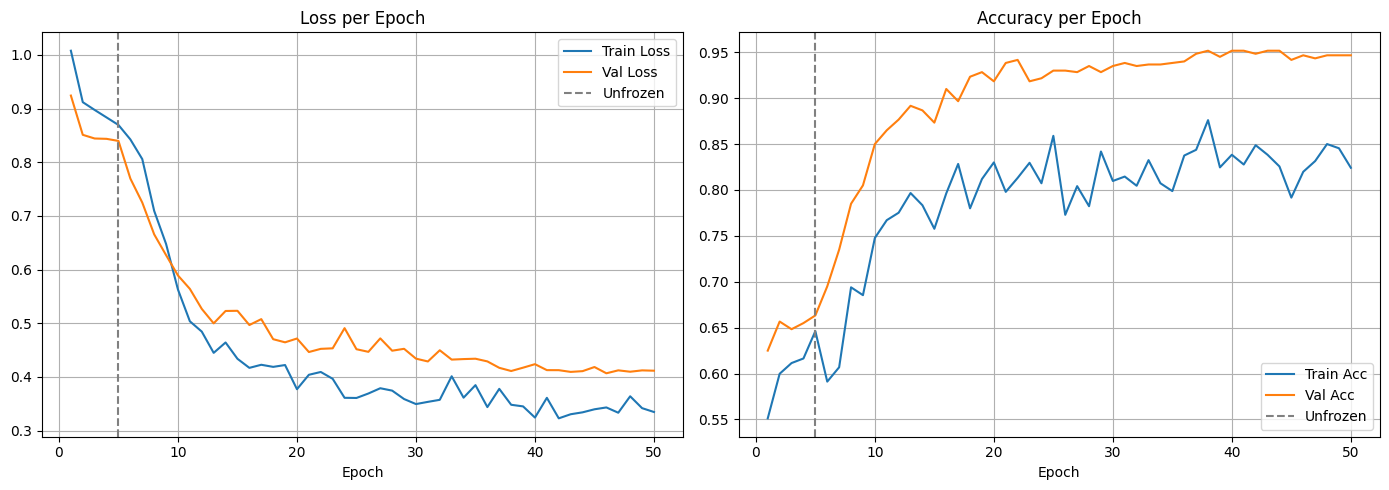

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss')
axes[0].axvline(WARMUP_EPOCHS, color='grey', linestyle='--', label='Unfrozen')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc')
axes[1].axvline(WARMUP_EPOCHS, color='grey', linestyle='--', label='Unfrozen')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('learning_curves_v4.png', dpi=150)
plt.show()

gap = np.array(history['train_acc']) - np.array(history['val_acc'])



Running TTA on test set...
TEST SET RESULTS (with TTA)
              precision    recall  f1-score   support

  1st Degree       0.89      0.96      0.93       200
  2nd Degree       0.92      0.85      0.88       200
  3rd Degree       0.94      0.94      0.94       200

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600



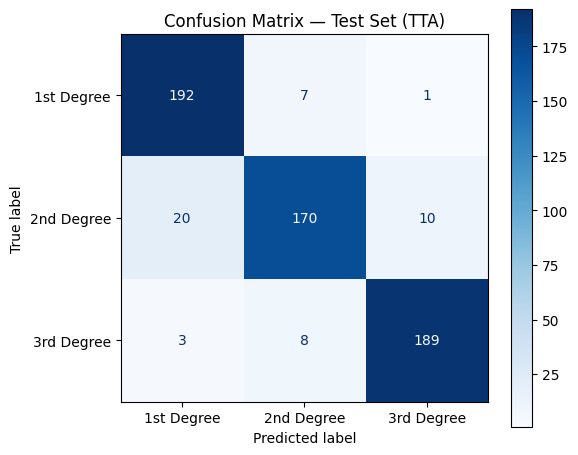

In [ ]:
def tta_predict(model, dataset, tta_transforms_list):
    model.eval()
    all_probs, all_labels = [], []
    for idx in range(len(dataset)):
        row   = dataset.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['label'])
        aug_probs = []
        for tfm in tta_transforms_list:
            tensor = tfm(image).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = F.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
            aug_probs.append(prob)
        all_probs.append(np.mean(aug_probs, axis=0))
        all_labels.append(label)
    return np.argmax(all_probs, axis=1), all_labels
tta_preds, tta_labels = tta_predict(model, test_dataset, tta_transforms)

print('=' * 55)
print('TEST SET RESULTS (with TTA)')
print('=' * 55)
print(classification_report(tta_labels, tta_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(tta_labels, tta_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set (TTA)')
plt.tight_layout()
plt.savefig('confusion_matrix_v4.png', dpi=150)
plt.show()
